# Data Preprocessing:

1.	Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary.
2.	Perform exploratory data analysis (EDA) to gain insights into the distribution of data and identify potential clusters.
3.	Use multiple visualizations to understand the hidden patterns in the dataset


In [24]:
import numpy as np
import pandas as pd


In [25]:
df=pd.read_excel('EastWestAirlines.xlsx',sheet_name='data')


In [26]:
df

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1
...,...,...,...,...,...,...,...,...,...,...,...,...
3994,4017,18476,0,1,1,1,8525,4,200,1,1403,1
3995,4018,64385,0,1,1,1,981,5,0,0,1395,1
3996,4019,73597,0,3,1,1,25447,8,0,0,1402,1
3997,4020,54899,0,1,1,1,500,1,500,1,1401,0


In [27]:
df.shape

(3999, 12)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


checking is there any missing values

In [29]:
df.isnull().sum()

,0
ID#,0
Balance,0
Qual_miles,0
cc1_miles,0
cc2_miles,0
cc3_miles,0
Bonus_miles,0
Bonus_trans,0
Flight_miles_12mo,0
Flight_trans_12,0


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

detecting outliers

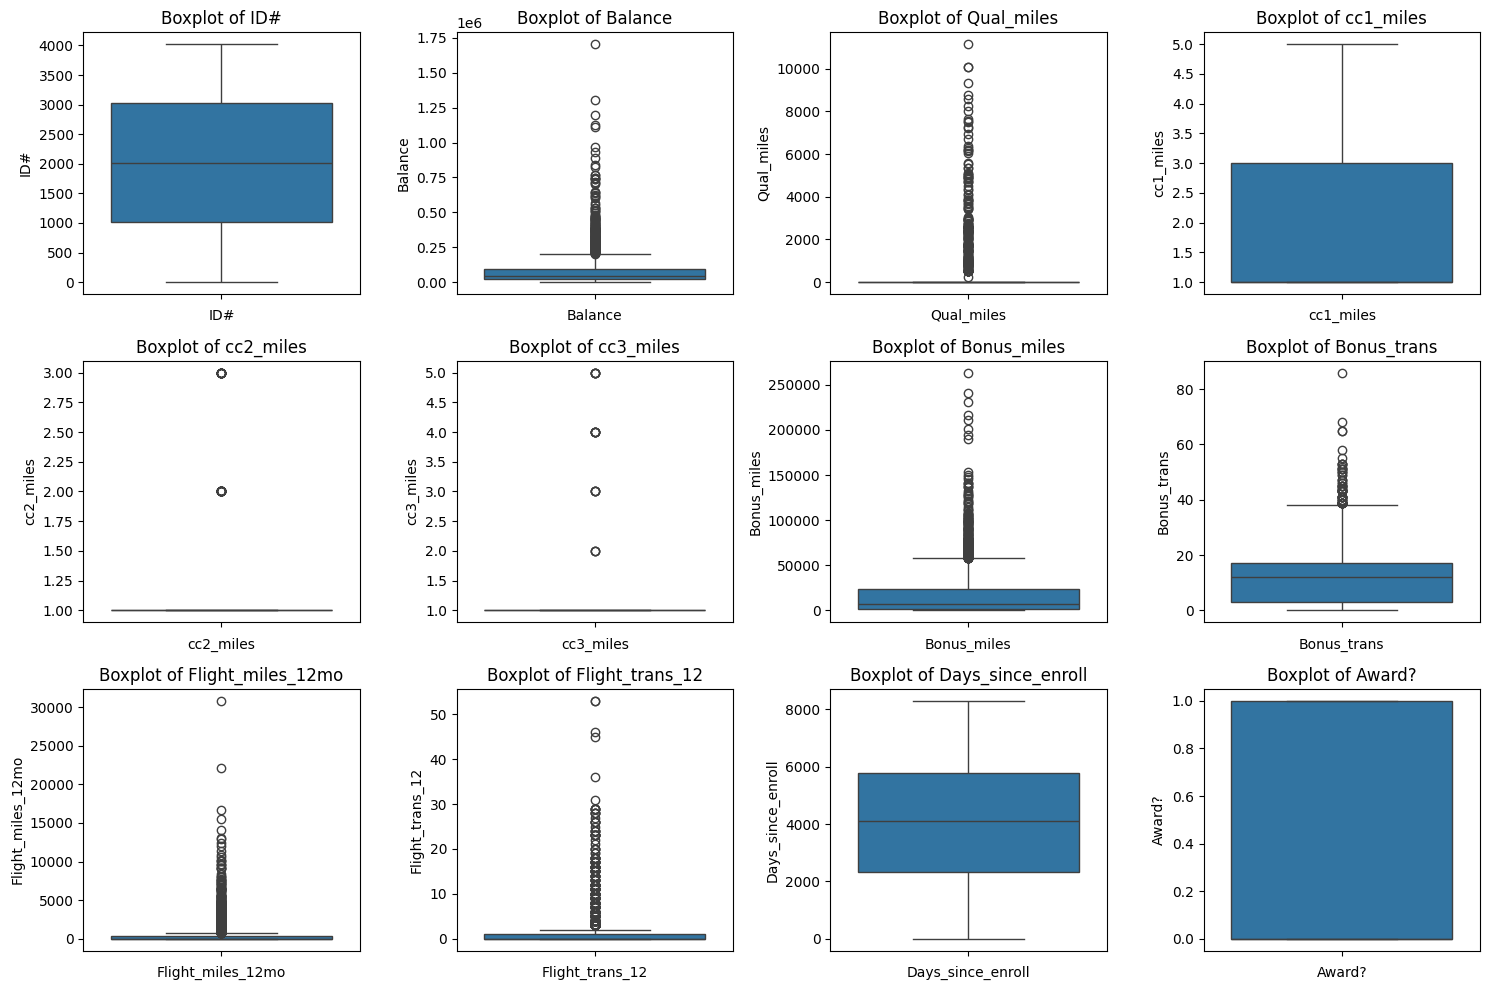

In [31]:
plt.figure(figsize=(15,10))
for i,col in enumerate(df.columns):
    plt.subplot(3,4,i+1)
    sns.boxplot(y=df[col])
    plt.xlabel(col)
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

treating outliers

In [32]:
handle=['Balance','Qual_miles','Bonus_miles','Bonus_trans','Flight_miles_12mo','Flight_trans_12']
for col in handle:
  q1= df[col].quantile(0.25)
  q3= df[col].quantile(0.75)
  iqr=q3-q1
  lower_bound=q1-1.5*iqr
  upper_bound=q3+1.5*iqr
  df[col]=np.where(df[col]<lower_bound,lower_bound,df[col])
  df[col]=np.where(df[col]>upper_bound,upper_bound,df[col])
  print(f'{col} handled outliers successfully')

Balance handled outliers successfully
Qual_miles handled outliers successfully
Bonus_miles handled outliers successfully
Bonus_trans handled outliers successfully
Flight_miles_12mo handled outliers successfully
Flight_trans_12 handled outliers successfully


In [33]:
scaling=df.columns.drop('ID#')
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
df[scaling]=scaler.fit_transform(df[scaling])
df[scaling]

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,0.138486,0.0,0.00,0.0,0.0,0.003019,0.026316,0.000000,0.0,0.843742,0.0
1,0.094696,0.0,0.00,0.0,0.0,0.003731,0.052632,0.000000,0.0,0.839884,0.0
2,0.203495,0.0,0.00,0.0,0.0,0.071547,0.105263,0.000000,0.0,0.847842,0.0
3,0.072710,0.0,0.00,0.0,0.0,0.008677,0.026316,0.000000,0.0,0.837955,0.0
4,0.481019,0.0,0.75,0.0,0.0,0.751394,0.684211,1.000000,1.0,0.835905,1.0
...,...,...,...,...,...,...,...,...,...,...,...
3994,0.090917,0.0,0.00,0.0,0.0,0.147936,0.105263,0.257235,0.4,0.168917,1.0
3995,0.316826,0.0,0.00,0.0,0.0,0.017023,0.131579,0.000000,0.0,0.167953,1.0
3996,0.362157,0.0,0.50,0.0,0.0,0.441587,0.210526,0.000000,0.0,0.168797,1.0
3997,0.270147,0.0,0.00,0.0,0.0,0.008677,0.026316,0.643087,0.4,0.168676,0.0


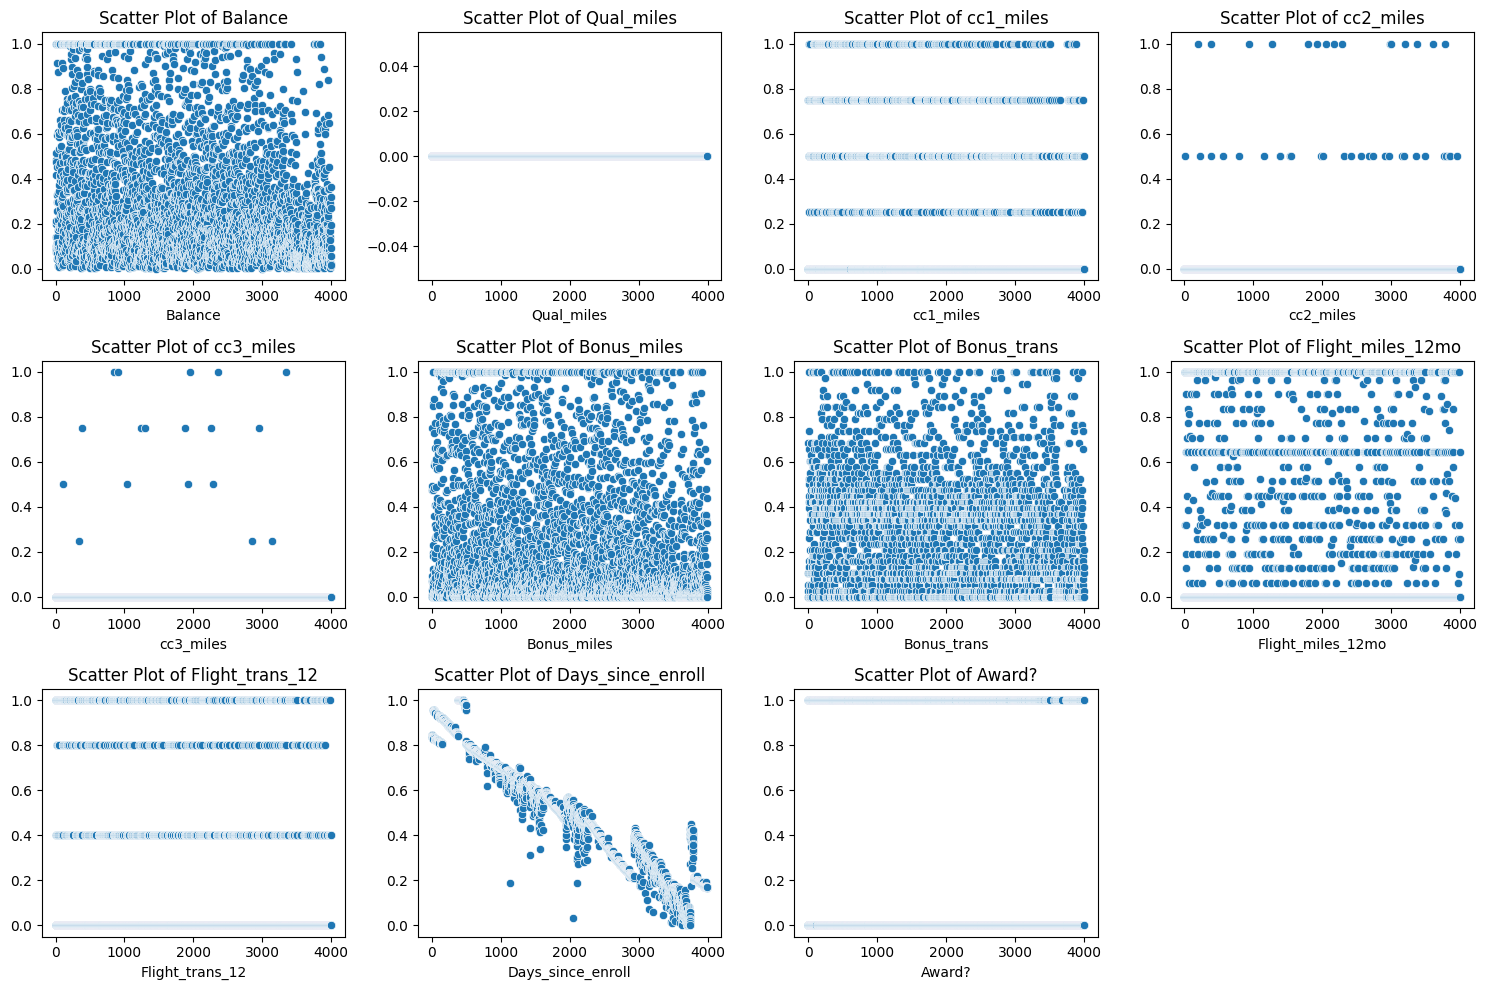

In [34]:
plt.figure(figsize=(15,10))
for i, col in enumerate(df[scaling]):

    plt.subplot(3,4,i+1)
    sns.scatterplot(x=df.index, y=df[col])
    plt.xlabel(col)
    plt.ylabel('')
    plt.title(f'Scatter Plot of {col}')


plt.tight_layout()
plt.show()



In [35]:
df=df.drop('ID#',axis=1)

heat map for the correlation between variables

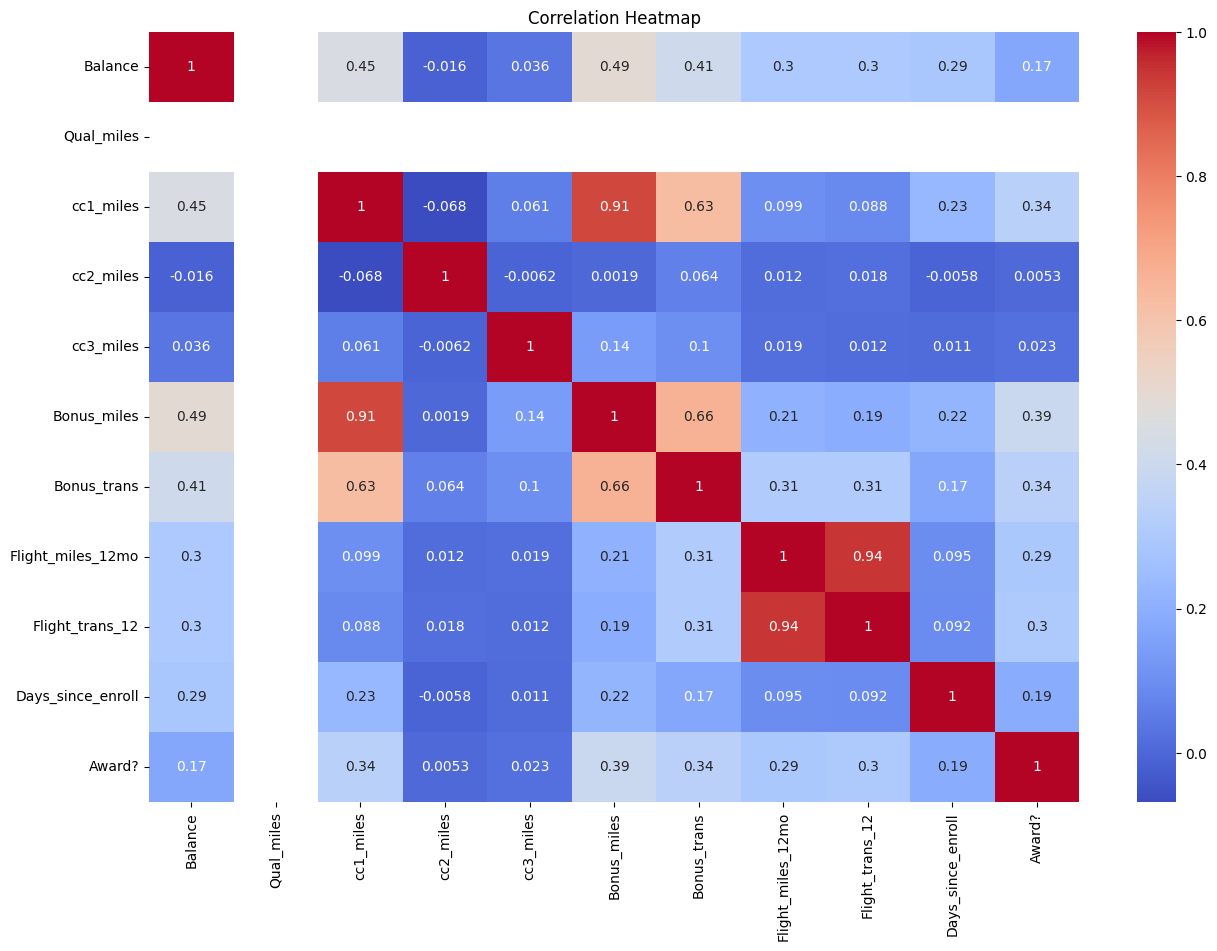

In [36]:

plt.figure(figsize=(15,10))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

strong positives :  

*   Flight_miles_12mo and Flight_trans_12
*   Bonus_miles and cc1_miles







<Figure size 1500x1000 with 0 Axes>

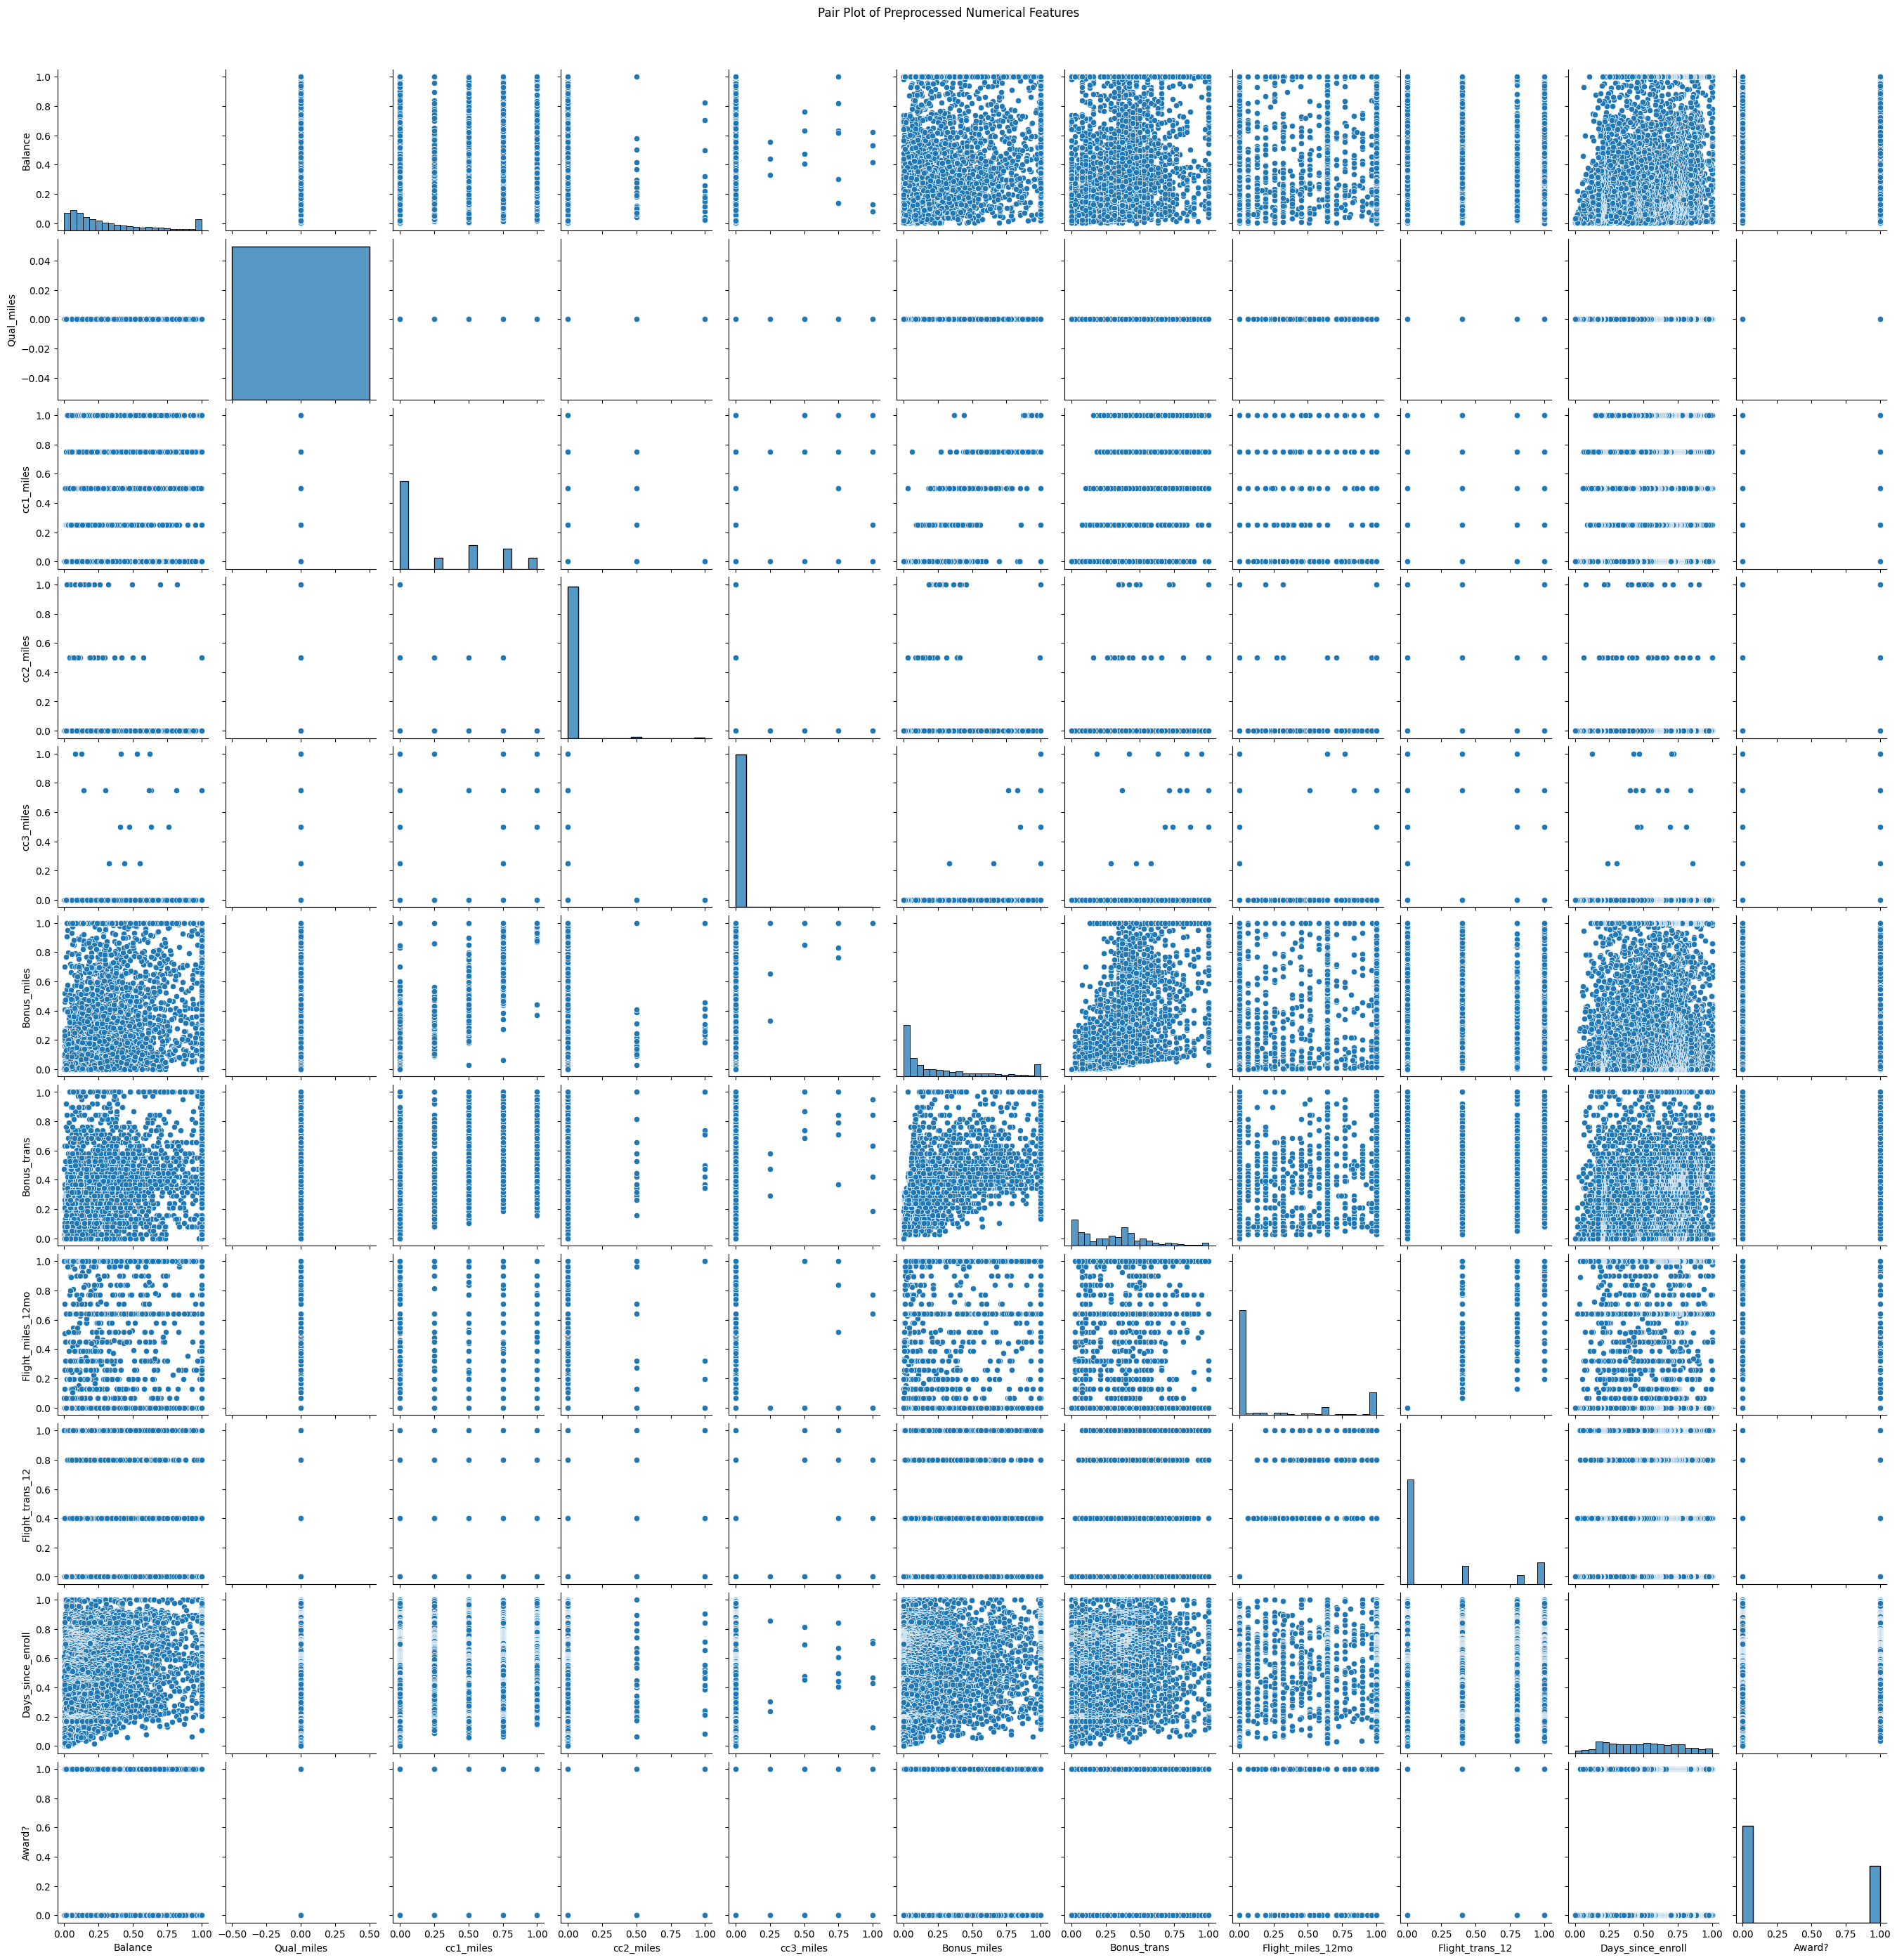

In [37]:
plt.figure(figsize=(15, 10))
sns.pairplot(df)
plt.suptitle('Pair Plot of Preprocessed Numerical Features', y=1.02)
plt.show()

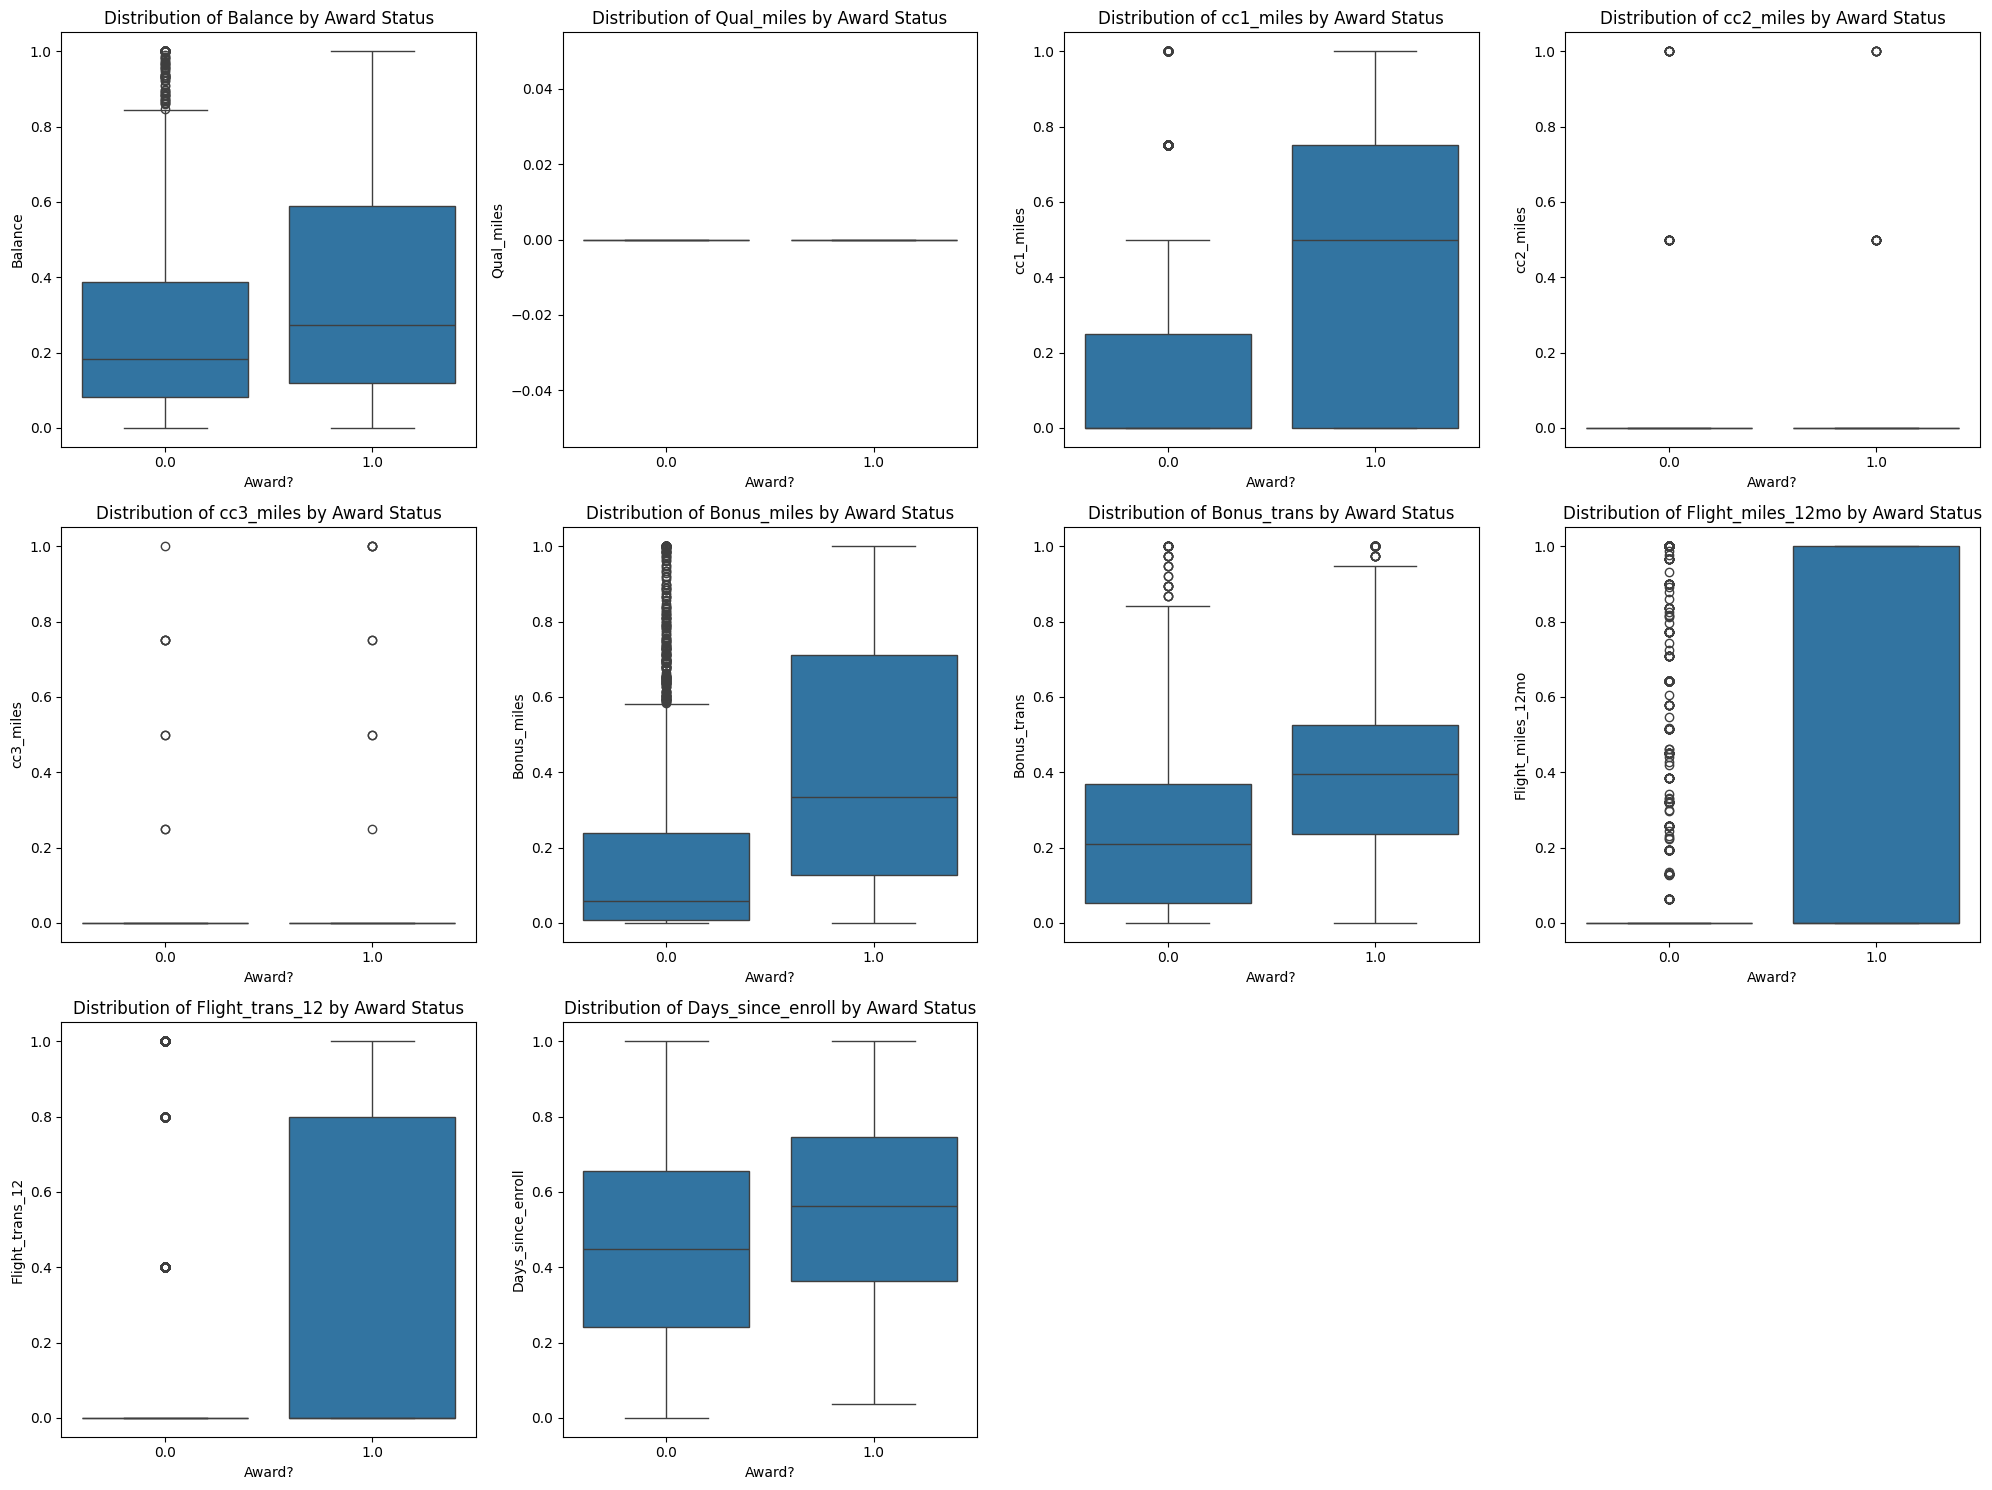

In [38]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(df.columns.drop('Award?')):
    plt.subplot(3, 4, i + 1)
    sns.boxplot(y=df[col], x=df['Award?'])
    plt.title(f'Distribution of {col} by Award Status')
    plt.xlabel('Award?')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

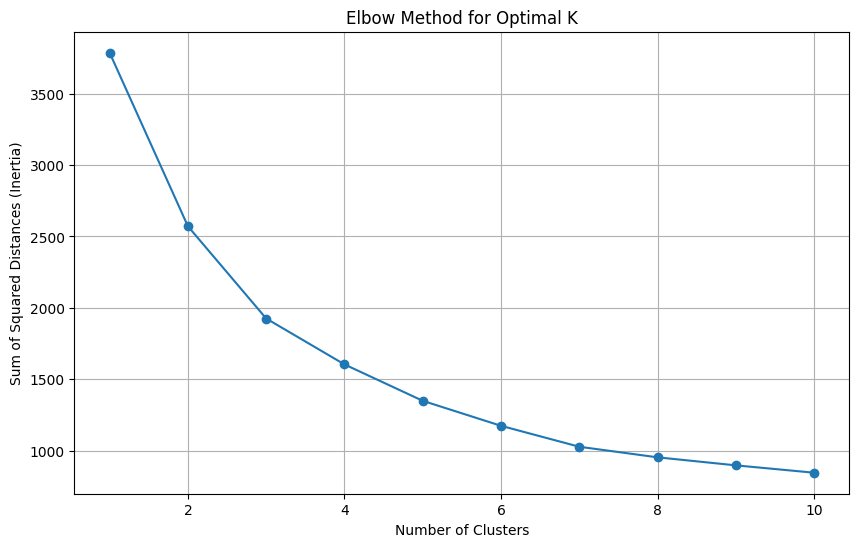

In [39]:
from sklearn.cluster import KMeans
inertia = []

for i in range(1, 11):

    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(df)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Sum of Squared Distances (Inertia)')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.show()

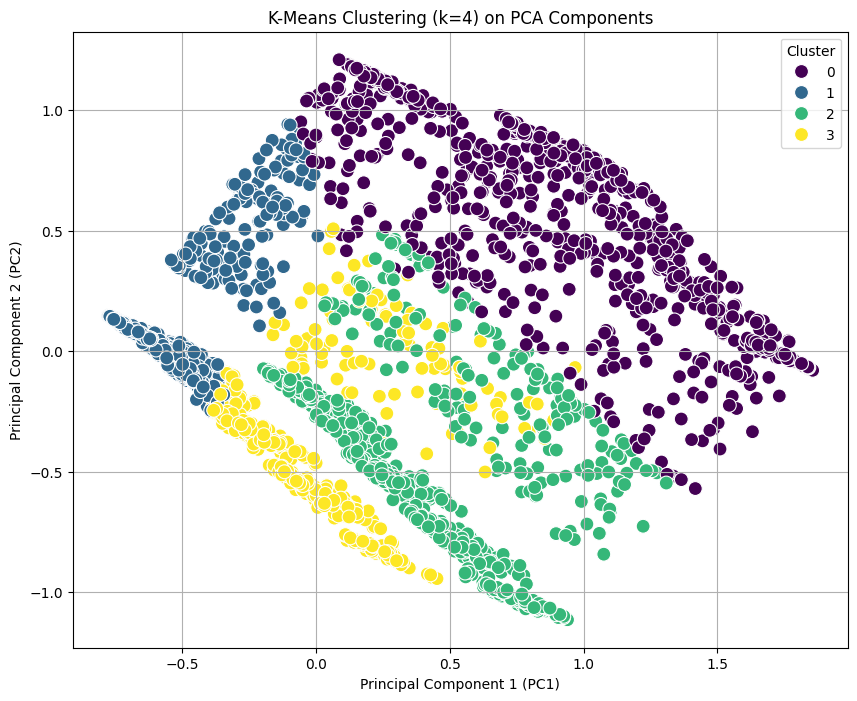

In [40]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


pca = PCA(n_components=2)
principal_components = pca.fit_transform(df)


pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

kmeans.fit(df)

pca_df['Cluster'] = kmeans.labels_


plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='viridis', s=100)
plt.title('K-Means Clustering (k=4) on PCA Components')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.grid(True)
plt.legend(title='Cluster')
plt.show()

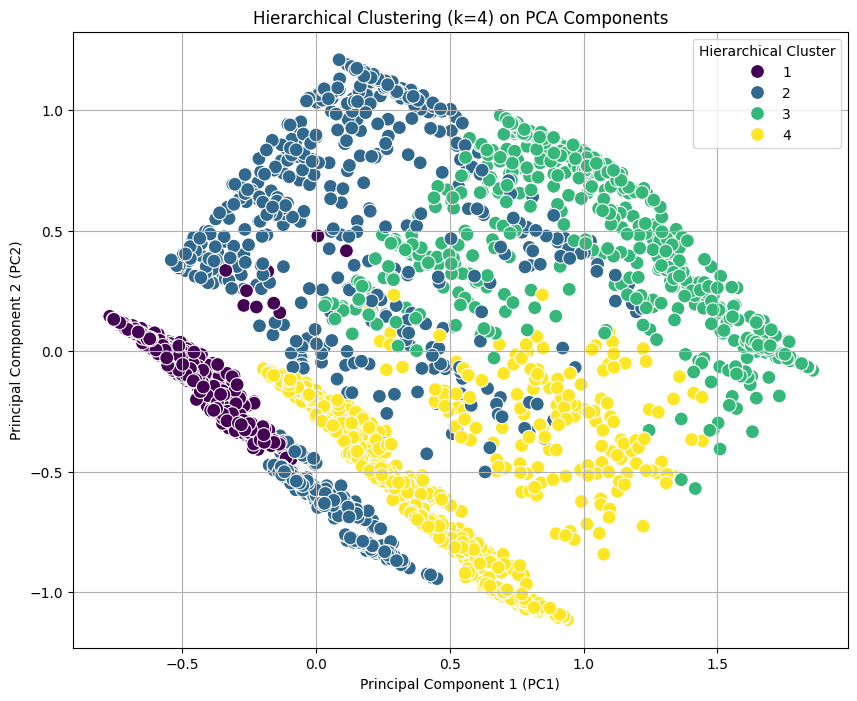

In [42]:
from scipy.cluster.hierarchy import fcluster, linkage
import matplotlib.pyplot as plt
import seaborn as sns


linked = linkage(df, method='ward', metric='euclidean')


hierarchical_clusters = fcluster(linked, t=4, criterion='maxclust')


pca_df['Hierarchical_Cluster'] = hierarchical_clusters


plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Hierarchical_Cluster', data=pca_df, palette='viridis', s=100)
plt.title('Hierarchical Clustering (k=4) on PCA Components')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.grid(True)
plt.legend(title='Hierarchical Cluster')
plt.show()

## DBSCAN Clustering




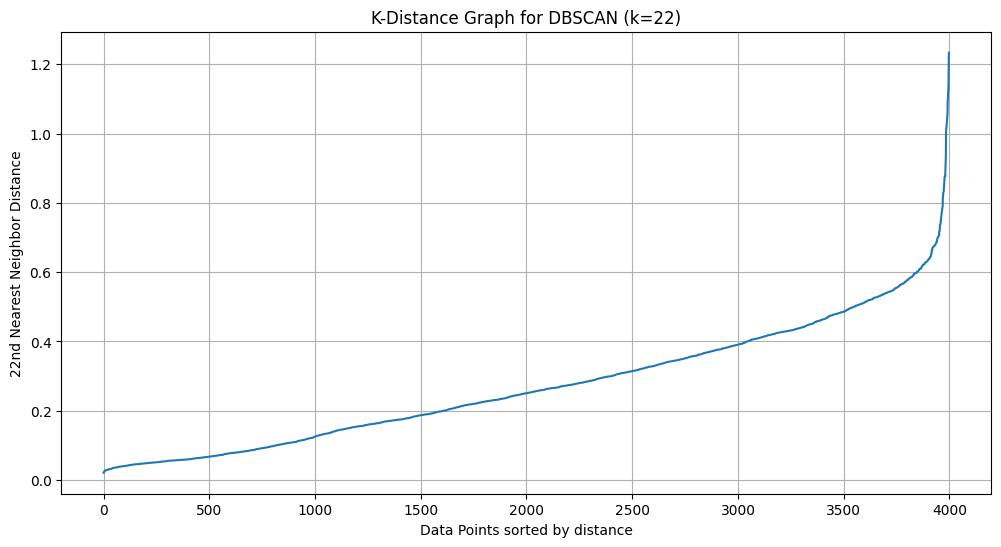

In [45]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=22)

neighbors_fit = neighbors.fit(df)


distances, indices = neighbors_fit.kneighbors(df)

distances = np.sort(distances[:, 21], axis=0)

# Plot the sorted distances (k-distance graph)
plt.figure(figsize=(12, 6))
plt.plot(distances)
plt.title('K-Distance Graph for DBSCAN (k=22)')
plt.xlabel('Data Points sorted by distance')
plt.ylabel('22nd Nearest Neighbor Distance')
plt.grid(True)
plt.show()

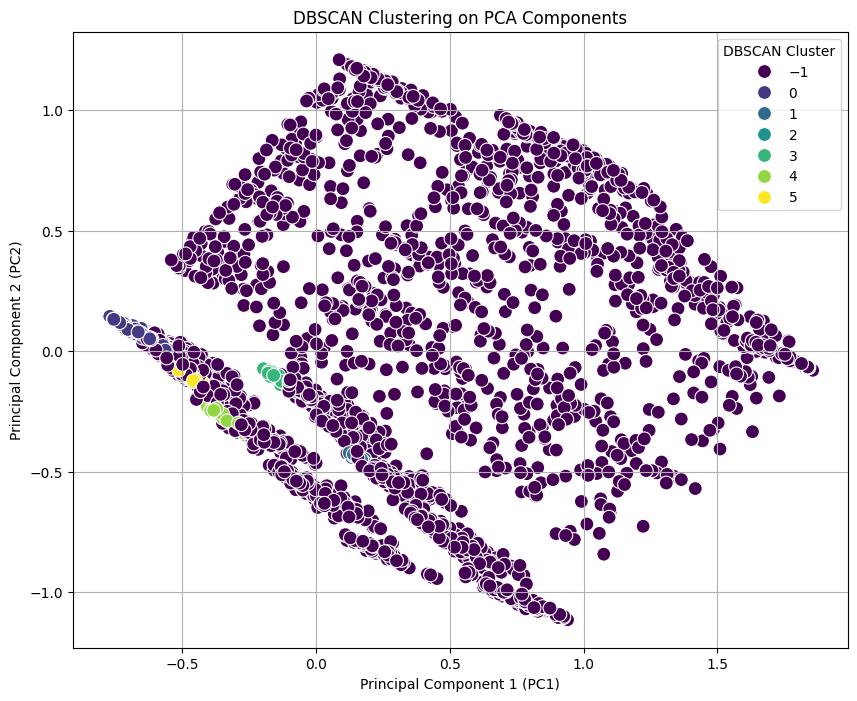

In [46]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.15, min_samples=22)

dbscan.fit(df)


pca_df['DBSCAN_Cluster'] = dbscan.labels_

# Create a scatter plot of the PCA components colored by DBSCAN cluster
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='DBSCAN_Cluster', data=pca_df, palette='viridis', s=100)
plt.title('DBSCAN Clustering on PCA Components')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.grid(True)
plt.legend(title='DBSCAN Cluster')
plt.show()

## Summary:

*   **K-Means Clustering**:
    *   The Elbow Method suggested an optimal number of **4 clusters**.
    *   The clusters were observed to be relatively well-separated in the 2D PCA space, with varying degrees of distinctness and some overlap between Clusters 1, 2, and 3.
    *   K-Means is characterized by its simplicity and efficiency, but it assumes spherical and equally sized clusters and is sensitive to the initial centroids and the pre-definition of `k`.
*   **Hierarchical Clustering**:
    *   When cut at **4 clusters** (similar to K-Means), it also produced 4 groups, with the dendrogram providing a visual hierarchy of cluster formation.
    *   It offers flexibility in determining the number of clusters without re-running the algorithm but can be computationally intensive for large datasets and decisions made during merging are irreversible.
    *   The 'ward' linkage method was used, which aims to minimize the variance within each cluster.
*   **DBSCAN Clustering**:
    *   DBSCAN identified a different number of clusters compared to K-Means and Hierarchical Clustering, and notably, it identified a significant number of **noise points** (labeled -1).
    *   The `eps` value was determined to be **0.15** from the k-distance graph, and `min_samples` was set to **22** (based on $2 \times \text{number of features}$).
    *   This algorithm is strong at identifying arbitrarily shaped clusters and handling noise but is highly sensitive to its `eps` and `min_samples` parameters.





*   **K-Means** offers a straightforward and interpretable way to divide customers into distinct groups, assuming these groups are roughly spherical and similar in size. It's excellent for creating easily actionable segments.
*   **Hierarchical Clustering** provides a more flexible view, allowing for exploration of segmentation at various granularities. It's good for understanding the natural relationships between customers and identifying nested groups.
*   **DBSCAN** is particularly powerful if there are significant outliers or if customer segments have irregular shapes or varying densities. The identification of noise points is a key advantage, as these might represent unique or problematic customer behaviors that require separate attention.


all three algorithms offer valuable insights. K-Means provides a simple baseline. Hierarchical clustering adds depth to understanding the relationships between segments. However, DBSCAN's ability to identify noise and arbitrary shapes might be most insightful if there are truly unique customer behaviors or non-obvious segments.

In [47]:
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(df, pca_df['Cluster'])
print(f"The silhouette score for K-Means clustering is: {silhouette_avg}")

The silhouette score for K-Means clustering is: 0.3452910553320466


In [48]:
silhouette_avg_hierarchical = silhouette_score(df, pca_df['Hierarchical_Cluster'])
print(f"The silhouette score for Hierarchical clustering is: {silhouette_avg_hierarchical}")

The silhouette score for Hierarchical clustering is: 0.34655241388346136


In [49]:
dbscan_filtered_df = df[pca_df['DBSCAN_Cluster'] != -1]
dbscan_filtered_labels = pca_df[pca_df['DBSCAN_Cluster'] != -1]['DBSCAN_Cluster']

if len(np.unique(dbscan_filtered_labels)) > 1:
    silhouette_avg_dbscan = silhouette_score(dbscan_filtered_df, dbscan_filtered_labels)
    print(f"The silhouette score for DBSCAN clustering (excluding noise) is: {silhouette_avg_dbscan}")
else:
    print("Cannot calculate silhouette score for DBSCAN: Less than 2 clusters found after excluding noise points.")

The silhouette score for DBSCAN clustering (excluding noise) is: 0.2893753181543411
